# Notebook 3 — Temporal Dynamics: Memory, Volatility & Relationships

**Inputs:** `soil_long.csv` (from Notebook 1)  
**Scope:** Characterise *how* soil properties change over time — not just what values they take, but whether change is persistent, mean-reverting, volatile, or structured. Layers build in order:

1. Regional trend layer — aggregate mean ± std per decade  
2. Country-level trend layer  
3. Hurst exponent maps — memory / persistence per location  
4. Volatility maps — coefficient of variation  
5. Hurst × CV quadrant — behavioural archetypes  
6. Correlation evolution — pairwise variable relationships over time  
7. SSBI delta map — composite soil behaviour shift

In [1]:
# ── 3.1  Imports & style ─────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

from scipy.stats import pearsonr

# ── Palette (mirrored from Notebooks 1 & 2) ──────────────────────────────────
PALETTE = {
    "acid":     "#8B0000",
    "neutral":  "#2E7D32",
    "alkaline": "#1E88E5",
    "sand":     "#F5E6C4",
    "charcoal": "#2B2B2B"
}
VAR_COLORS = {"clay": "#A0522D", "ph": "#1E88E5", "orgc": "#2E7D32"}
VAR_LABELS = {"clay": "Clay (%)", "ph": "pH", "orgc": "Organic Carbon (%)"}
COUNTRY_COLORS = {
    "South Africa": PALETTE["acid"],
    "Botswana":     PALETTE["neutral"],
    "Namibia":      PALETTE["alkaline"],
    "Mozambique":   "#FF8C00",
    "Lesotho":      "#6A0DAD",
    "Swaziland":    "#00796B",
    "Zimbabwe":     "#5D4037"
}
BBOX     = {"lon_min": 11.5, "lon_max": 40.0, "lat_min": -35.0, "lat_max": -15.0}
GRID_BIN = 2.0   # degrees — spatial aggregation bin for building per-cell time series

plt.rcParams.update({
    "figure.figsize":   (8, 5),
    "axes.facecolor":   PALETTE["sand"],
    "figure.facecolor": PALETTE["sand"],
    "text.color":       PALETTE["charcoal"]
})
def clean_plot():
    plt.grid(True, linestyle='--', alpha=0.3)
    plt.tight_layout()

print("Style loaded.")

Style loaded.


## 3.2 Load data & spatial binning

Each record is assigned to a 2° × 2° grid cell. Cells become the unit of time series analysis: we aggregate readings per cell × decade × variable, then compute temporal metrics on each cell's series.

In [2]:
soil_long = pd.read_csv("soil_long.csv")

surface = soil_long[
    (soil_long["depth_category"] == "Surface") &
    soil_long["decade"].notna() &
    soil_long["value_avg"].notna()
].copy()

# Spatial bins
surface["lon_bin"] = (surface["longitude"] // GRID_BIN) * GRID_BIN
surface["lat_bin"] = (surface["latitude"]  // GRID_BIN) * GRID_BIN
surface["cell_id"] = (surface["lon_bin"].astype(str) + "_"
                      + surface["lat_bin"].astype(str))

DECADE_ORDER = sorted(surface["decade"].unique())
print(f"Surface records: {len(surface):,}")
print(f"Decades        : {DECADE_ORDER}")
print(f"Unique 2°×2° cells: {surface['cell_id'].nunique()}")

Surface records: 6,724
Decades        : ['1940s', '1960s', '1970s', '1980s', '1990s', '2000s']
Unique 2°×2° cells: 47


In [3]:
# Aggregate to cell × decade × variable — the temporal analysis base table
cell_agg = (
    surface
    .groupby(["cell_id", "lon_bin", "lat_bin", "variable", "decade"])["value_avg"]
    .mean()
    .reset_index()
    .rename(columns={"value_avg": "cell_mean"})
)
print(f"Cell aggregations: {len(cell_agg):,} rows")
print(f"Unique cells     : {cell_agg['cell_id'].nunique()}")
cell_agg.head()

Cell aggregations: 278 rows
Unique cells     : 47


,cell_id,lon_bin,lat_bin,variable,decade,cell_mean
0,16.0_-24.0,16.0,-24.0,clay,1970s,5.552941
1,16.0_-24.0,16.0,-24.0,clay,2000s,2.925000
2,16.0_-24.0,16.0,-24.0,orgc,1970s,4.950000
3,16.0_-24.0,16.0,-24.0,orgc,2000s,5.800000
4,16.0_-24.0,16.0,-24.0,ph,1970s,7.550000


## 3.3 Regional trend layer

Regional mean ± 1 standard deviation per variable per decade. This is the broadest temporal signal — before zooming in on individual cells.

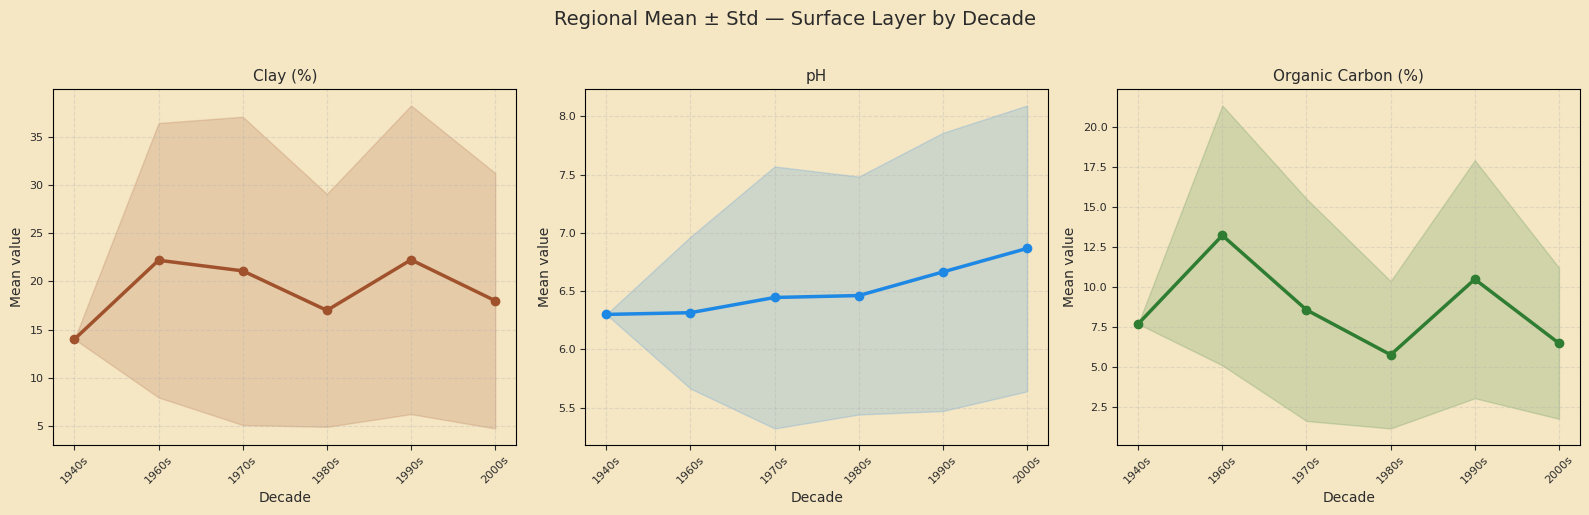

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.patch.set_facecolor(PALETTE["sand"])

for ax, var in zip(axes, ["clay", "ph", "orgc"]):
    regional = (
        surface[surface["variable"] == var]
        .groupby("decade")["value_avg"]
        .agg(["mean", "std"])
        .reindex(DECADE_ORDER)
    )
    ax.plot(regional.index, regional["mean"],
            color=VAR_COLORS[var], linewidth=2.5, marker="o", markersize=6)
    ax.fill_between(
        regional.index,
        regional["mean"] - regional["std"],
        regional["mean"] + regional["std"],
        color=VAR_COLORS[var], alpha=0.18
    )
    ax.set_title(VAR_LABELS[var], color=PALETTE["charcoal"], fontsize=11)
    ax.set_xlabel("Decade",       color=PALETTE["charcoal"])
    ax.set_ylabel("Mean value",   color=PALETTE["charcoal"])
    ax.set_facecolor(PALETTE["sand"])
    ax.tick_params(colors=PALETTE["charcoal"], labelsize=8)
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)
    ax.grid(True, linestyle="--", alpha=0.3)

plt.suptitle("Regional Mean ± Std — Surface Layer by Decade",
             color=PALETTE["charcoal"], fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 3.4 Country-level trends

Disaggregate by country to reveal whether regional patterns mask divergent national trajectories.

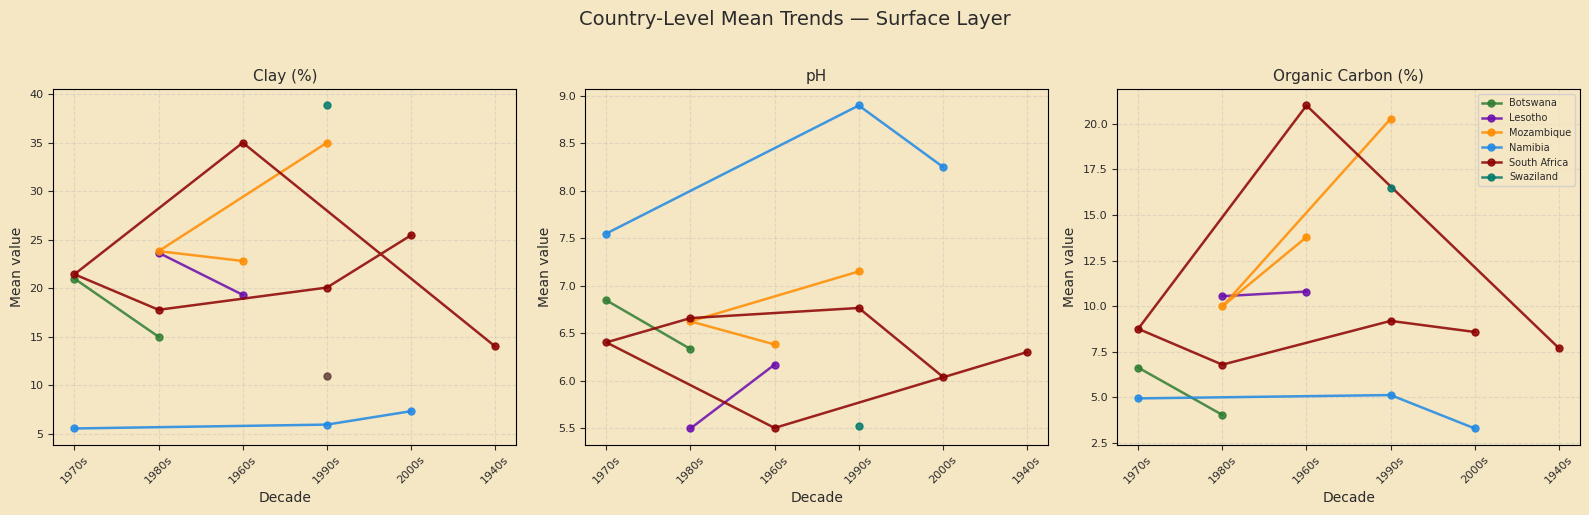

In [5]:
country_agg = (
    surface
    .groupby(["country_name", "variable", "decade"])["value_avg"]
    .mean()
    .reset_index()
)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.patch.set_facecolor(PALETTE["sand"])

for ax, var in zip(axes, ["clay", "ph", "orgc"]):
    sub = country_agg[country_agg["variable"] == var]
    for country, grp in sub.groupby("country_name"):
        grp_s = grp.sort_values("decade")
        ax.plot(grp_s["decade"], grp_s["value_avg"],
                color=COUNTRY_COLORS.get(country, "#888888"),
                linewidth=1.8, marker="o", markersize=5,
                label=country, alpha=0.85)
    ax.set_title(VAR_LABELS[var], color=PALETTE["charcoal"], fontsize=11)
    ax.set_xlabel("Decade",       color=PALETTE["charcoal"])
    ax.set_ylabel("Mean value",   color=PALETTE["charcoal"])
    ax.set_facecolor(PALETTE["sand"])
    ax.tick_params(colors=PALETTE["charcoal"], labelsize=8)
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)
    ax.grid(True, linestyle="--", alpha=0.3)
    if var == "orgc":
        ax.legend(fontsize=7, facecolor=PALETTE["sand"], labelcolor=PALETTE["charcoal"])

plt.suptitle("Country-Level Mean Trends — Surface Layer",
             color=PALETTE["charcoal"], fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 3.5 Hurst exponent

The **Hurst exponent H** characterises the *memory* of a time series:

| H | Interpretation |
|---|---|
| H < 0.5 | Mean-reverting — deviations self-correct |
| H ≈ 0.5 | Random walk — no persistent structure |
| H > 0.5 | Persistent — trends tend to continue |

Computed here via R/S (rescaled range) analysis on each cell's decade-aggregated series. A minimum of 4 decade-observations is required per cell.

In [6]:
def hurst_exponent(ts):
    """
    Estimate Hurst exponent via R/S analysis over multiple lags.

    Parameters
    ----------
    ts : array-like
        Time series values (NaNs are dropped before computation).

    Returns
    -------
    float : H in [0, 1], or NaN if the series is too short.
    """
    ts    = np.asarray(ts, dtype=float)
    ts    = ts[~np.isnan(ts)]
    n     = len(ts)
    if n < 4:
        return np.nan

    max_lag = min(n // 2, 8)
    if max_lag < 2:
        return np.nan

    lags = list(range(2, max_lag + 1))
    RS   = []

    for lag in lags:
        sub_series = [ts[i : i + lag] for i in range(0, n - lag + 1, lag)]
        rs_vals    = []
        for sub in sub_series:
            if len(sub) < 2:
                continue
            mean_s = np.mean(sub)
            dev    = sub - mean_s
            cumdev = np.cumsum(dev)
            R      = cumdev.max() - cumdev.min()
            S      = np.std(sub, ddof=1)
            if S > 0:
                rs_vals.append(R / S)
        if rs_vals:
            RS.append(np.mean(rs_vals))

    if len(RS) < 2:
        return np.nan

    H, _ = np.polyfit(np.log(lags[: len(RS)]), np.log(RS), 1)
    return float(H)


# Quick sanity checks
print(f"Sine-wave (should be persistent, H>0.5): "
      f"{hurst_exponent(np.sin(np.linspace(0, 4*np.pi, 20))):.3f}")
print(f"Random noise (should be ~0.5):           "
      f"{hurst_exponent(np.random.default_rng(42).standard_normal(40)):.3f}")

Sine-wave (should be persistent, H>0.5): 1.129
Random noise (should be ~0.5):           0.902


In [7]:
MIN_OBS = 4   # minimum decades per cell required for Hurst

hurst_records = []
for var in ["clay", "ph", "orgc"]:
    var_cells = cell_agg[cell_agg["variable"] == var]
    for cell_id, grp in var_cells.groupby("cell_id"):
        grp_s = grp.sort_values("decade")
        if len(grp_s) < MIN_OBS:
            continue
        H     = hurst_exponent(grp_s["cell_mean"].values)
        hurst_records.append({
            "variable": var,
            "cell_id":  cell_id,
            "lon_bin":  grp_s["lon_bin"].iloc[0],
            "lat_bin":  grp_s["lat_bin"].iloc[0],
            "H":        H
        })

hurst_df = pd.DataFrame(hurst_records)
print(f"Hurst computed : {len(hurst_df)} cell–variable pairs")
print(f"Valid (non-NaN): {hurst_df['H'].notna().sum()}")

# Fraction persistent / random / mean-reverting
for var in ["clay", "ph", "orgc"]:
    sub = hurst_df[(hurst_df["variable"] == var) & hurst_df["H"].notna()]["H"]
    if len(sub) == 0:
        print(f"\n{var}: no valid cells")
        continue
    print(f"\n{var:5s}  n={len(sub)}  "
          f"median H={sub.median():.3f}  "
          f"persistent(>0.55)={( sub>0.55).mean()*100:.0f}%  "
          f"mean-rev(<0.45)={(sub<0.45).mean()*100:.0f}%")

Hurst computed : 11 cell–variable pairs
Valid (non-NaN): 0

clay: no valid cells

ph: no valid cells

orgc: no valid cells


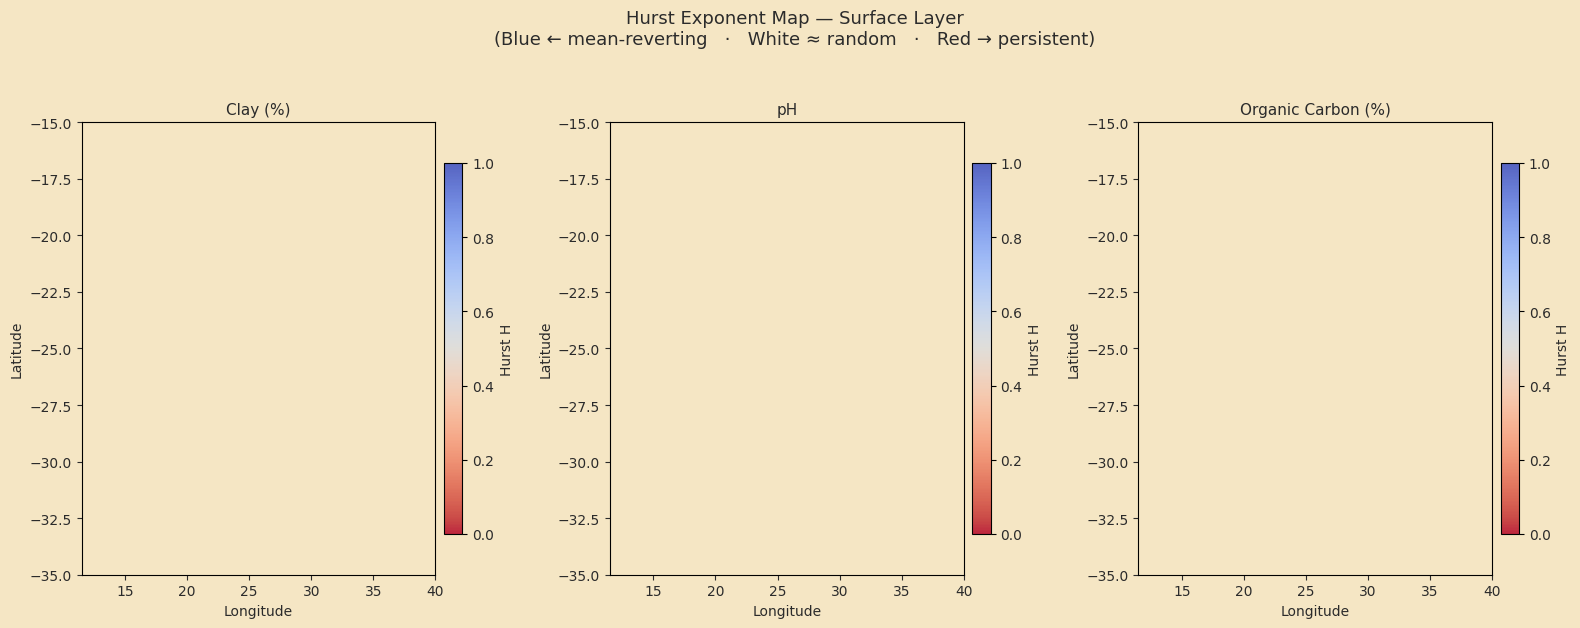

In [8]:
# ── Spatial maps of Hurst exponent ───────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 6))
fig.patch.set_facecolor(PALETTE["sand"])

for ax, var in zip(axes, ["clay", "ph", "orgc"]):
    sub = hurst_df[(hurst_df["variable"] == var) & hurst_df["H"].notna()]
    sc  = ax.scatter(
        sub["lon_bin"], sub["lat_bin"],
        c=sub["H"], cmap="coolwarm_r",
        vmin=0.0, vmax=1.0,
        s=100, edgecolors=PALETTE["charcoal"], linewidths=0.3, alpha=0.85
    )
    cb = plt.colorbar(sc, ax=ax, shrink=0.82, pad=0.02)
    cb.set_label("Hurst H", color=PALETTE["charcoal"])
    cb.ax.tick_params(labelcolor=PALETTE["charcoal"])
    ax.set_xlim(BBOX["lon_min"], BBOX["lon_max"])
    ax.set_ylim(BBOX["lat_min"], BBOX["lat_max"])
    ax.set_facecolor(PALETTE["sand"])
    ax.set_title(VAR_LABELS[var], color=PALETTE["charcoal"], fontsize=11)
    ax.set_xlabel("Longitude",   color=PALETTE["charcoal"])
    ax.set_ylabel("Latitude",    color=PALETTE["charcoal"])
    ax.tick_params(colors=PALETTE["charcoal"])

plt.suptitle("Hurst Exponent Map — Surface Layer\n"
             "(Blue ← mean-reverting   ·   White ≈ random   ·   Red → persistent)",
             color=PALETTE["charcoal"], fontsize=13, y=1.04)
plt.tight_layout()
plt.show()

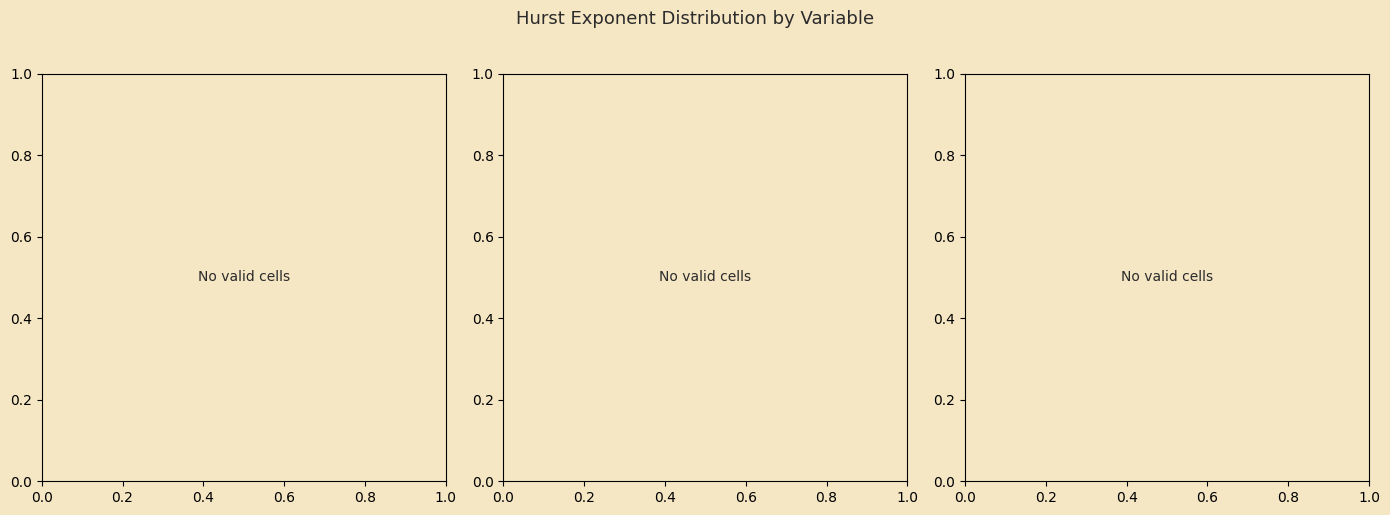

In [9]:
# ── Hurst distribution per variable ─────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.patch.set_facecolor(PALETTE["sand"])

for ax, var in zip(axes, ["clay", "ph", "orgc"]):
    sub = hurst_df[(hurst_df["variable"] == var) & hurst_df["H"].notna()]["H"]
    if len(sub) == 0:
        ax.text(0.5, 0.5, "No valid cells", ha="center", va="center",
                transform=ax.transAxes, color=PALETTE["charcoal"])
        continue
    ax.hist(sub, bins=15, color=VAR_COLORS[var], edgecolor="white", alpha=0.85)
    ax.axvline(0.5,          color=PALETTE["charcoal"], linestyle="--",
               linewidth=1.2, alpha=0.8, label="H = 0.5 (random)")
    ax.axvline(sub.median(), color=PALETTE["acid"],     linestyle=":",
               linewidth=1.5, label=f"Median = {sub.median():.2f}")
    ax.set_title(VAR_LABELS[var], color=PALETTE["charcoal"], fontsize=11)
    ax.set_xlabel("Hurst H",      color=PALETTE["charcoal"])
    ax.set_ylabel("Cell count",   color=PALETTE["charcoal"])
    ax.set_facecolor(PALETTE["sand"])
    ax.tick_params(colors=PALETTE["charcoal"])
    ax.legend(fontsize=8, facecolor=PALETTE["sand"], labelcolor=PALETTE["charcoal"])
    ax.grid(True, linestyle="--", alpha=0.3)

plt.suptitle("Hurst Exponent Distribution by Variable",
             color=PALETTE["charcoal"], fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 3.6 Volatility — Coefficient of Variation

The **coefficient of variation** (CV = σ/μ) measures how unstable a cell's soil property is across the measured decades. High CV cells flag locations with erratic temporal behaviour, independent of the direction of change.

In [10]:
cv_records = []
for var in ["clay", "ph", "orgc"]:
    var_cells = cell_agg[cell_agg["variable"] == var]
    for cell_id, grp in var_cells.groupby("cell_id"):
        vals  = grp["cell_mean"].dropna()
        if len(vals) < 2:
            continue
        mean_v = vals.mean()
        cv     = vals.std() / mean_v if mean_v > 0 else np.nan
        cv_records.append({
            "variable": var,
            "cell_id":  cell_id,
            "lon_bin":  grp["lon_bin"].iloc[0],
            "lat_bin":  grp["lat_bin"].iloc[0],
            "cv":       cv
        })

cv_df = pd.DataFrame(cv_records)
print(f"CV computed for {len(cv_df)} cell–variable pairs")

CV computed for 88 cell–variable pairs


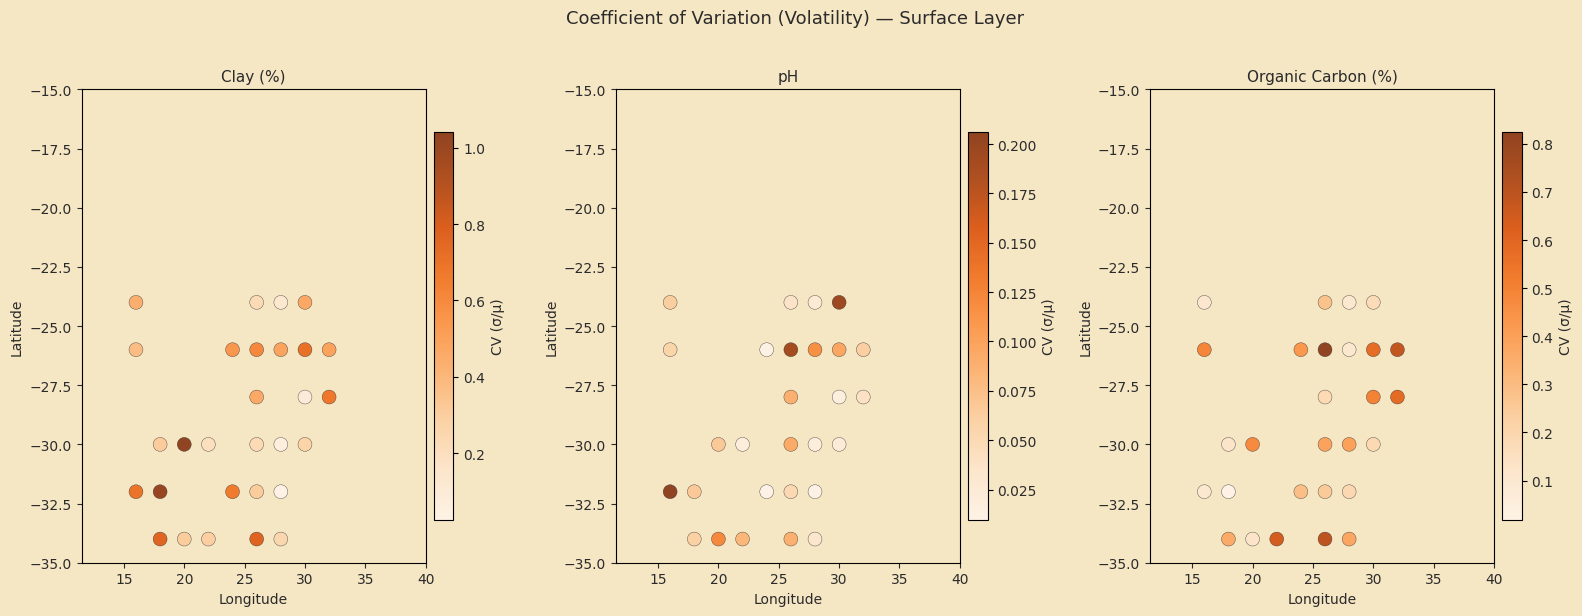

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(16, 6))
fig.patch.set_facecolor(PALETTE["sand"])

for ax, var in zip(axes, ["clay", "ph", "orgc"]):
    sub = cv_df[(cv_df["variable"] == var) & cv_df["cv"].notna()]
    sc  = ax.scatter(
        sub["lon_bin"], sub["lat_bin"],
        c=sub["cv"], cmap="Oranges",
        s=100, edgecolors=PALETTE["charcoal"], linewidths=0.3, alpha=0.85
    )
    cb = plt.colorbar(sc, ax=ax, shrink=0.82, pad=0.02)
    cb.set_label("CV (σ/μ)", color=PALETTE["charcoal"])
    cb.ax.tick_params(labelcolor=PALETTE["charcoal"])
    ax.set_xlim(BBOX["lon_min"], BBOX["lon_max"])
    ax.set_ylim(BBOX["lat_min"], BBOX["lat_max"])
    ax.set_facecolor(PALETTE["sand"])
    ax.set_title(VAR_LABELS[var], color=PALETTE["charcoal"], fontsize=11)
    ax.set_xlabel("Longitude",    color=PALETTE["charcoal"])
    ax.set_ylabel("Latitude",     color=PALETTE["charcoal"])
    ax.tick_params(colors=PALETTE["charcoal"])

plt.suptitle("Coefficient of Variation (Volatility) — Surface Layer",
             color=PALETTE["charcoal"], fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 3.7 Behavioural quadrant: Memory × Volatility

Combining Hurst and CV into a 2×2 classification reveals four qualitatively distinct soil behaviours:

| | **Low CV** (stable) | **High CV** (turbulent) |
|---|---|---|
| **H > 0.55** (persistent) | Steady Drift | Persistent & Turbulent |
| **H ≤ 0.55** (non-persistent) | Stable Equilibrium | Chaotic Fluctuation |

In [12]:
hv_df = pd.merge(
    hurst_df[["variable", "cell_id", "H"]],
    cv_df[["variable", "cell_id", "cv"]],
    on=["variable", "cell_id"]
).dropna()

H_THRESHOLD  = 0.55

def classify_behaviour(row, cv_median):
    h, cv = row["H"], row["cv"]
    if h > H_THRESHOLD and cv < cv_median:
        return "Steady Drift"
    elif h > H_THRESHOLD and cv >= cv_median:
        return "Persistent & Turbulent"
    elif h <= H_THRESHOLD and cv < cv_median:
        return "Stable Equilibrium"
    else:
        return "Chaotic Fluctuation"

for var in ["clay", "ph", "orgc"]:
    mask = hv_df["variable"] == var
    cv_med = hv_df.loc[mask, "cv"].median()
    hv_df.loc[mask, "behaviour"] = hv_df.loc[mask].apply(
        lambda r: classify_behaviour(r, cv_med), axis=1
    )

BEHAVIOUR_COLORS = {
    "Steady Drift":           PALETTE["neutral"],
    "Persistent & Turbulent": PALETTE["acid"],
    "Stable Equilibrium":     PALETTE["alkaline"],
    "Chaotic Fluctuation":    "#FF8C00"
}

# Print summary counts
print(hv_df.groupby(["variable", "behaviour"]).size().unstack(fill_value=0))

Empty DataFrame
Columns: []
Index: []


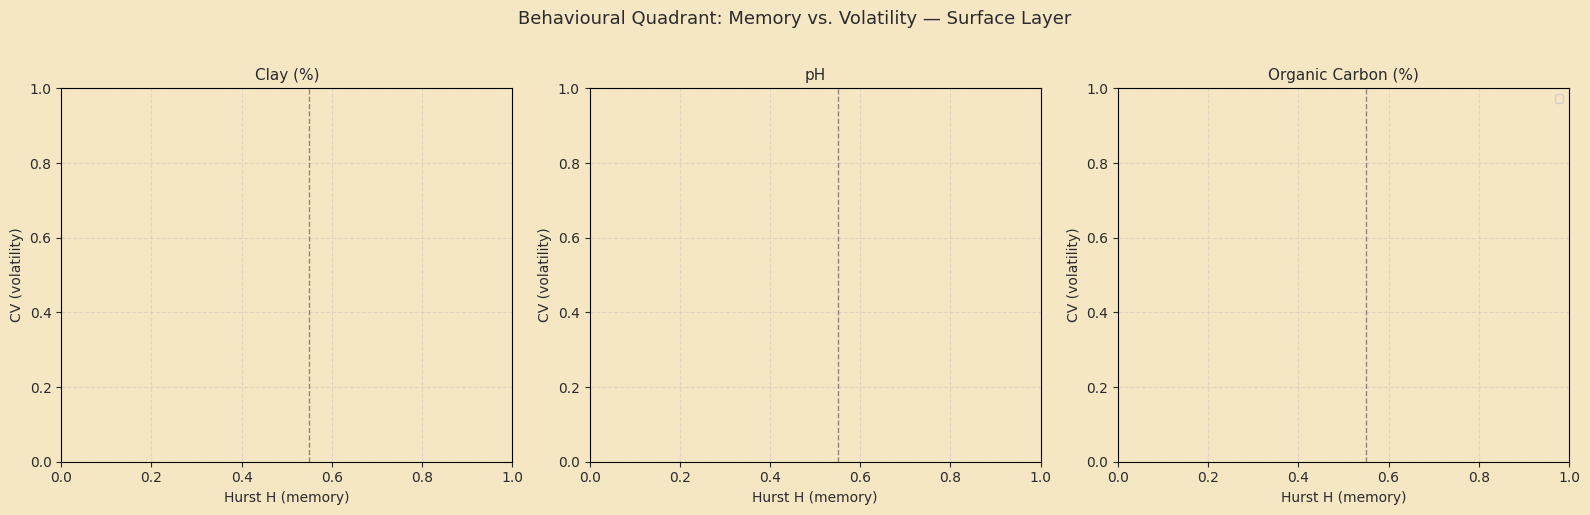

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.patch.set_facecolor(PALETTE["sand"])

for ax, var in zip(axes, ["clay", "ph", "orgc"]):
    sub = hv_df[hv_df["variable"] == var]
    cv_med = sub["cv"].median()

    for beh, grp in sub.groupby("behaviour"):
        ax.scatter(grp["H"], grp["cv"],
                   color=BEHAVIOUR_COLORS[beh],
                   s=60, alpha=0.82, label=beh,
                   edgecolors="white", linewidths=0.4)

    ax.axvline(H_THRESHOLD, color=PALETTE["charcoal"],
               linestyle="--", alpha=0.5, linewidth=1)
    ax.axhline(cv_med,       color=PALETTE["charcoal"],
               linestyle="--", alpha=0.5, linewidth=1)
    ax.set_title(VAR_LABELS[var], color=PALETTE["charcoal"], fontsize=11)
    ax.set_xlabel("Hurst H (memory)",   color=PALETTE["charcoal"])
    ax.set_ylabel("CV (volatility)",    color=PALETTE["charcoal"])
    ax.set_facecolor(PALETTE["sand"])
    ax.tick_params(colors=PALETTE["charcoal"])
    ax.grid(True, linestyle="--", alpha=0.3)
    if var == "orgc":
        ax.legend(fontsize=8, facecolor=PALETTE["sand"],
                  labelcolor=PALETTE["charcoal"])

plt.suptitle("Behavioural Quadrant: Memory vs. Volatility — Surface Layer",
             color=PALETTE["charcoal"], fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 3.8 Correlation evolution

How do pairwise relationships between clay, pH, and organic carbon shift across decades? Decoupling or strengthening correlations can indicate changing environmental drivers.

In [14]:
corr_records = []
for decade in DECADE_ORDER:
    decade_data = surface[surface["decade"] == decade]
    wide = (
        decade_data
        .groupby(["cell_id", "variable"])["value_avg"]
        .mean()
        .unstack()
    )
    for v1, v2 in [("clay", "orgc"), ("orgc", "ph"), ("clay", "ph")]:
        if v1 in wide.columns and v2 in wide.columns:
            pair = wide[[v1, v2]].dropna()
            if len(pair) >= 5:
                r, p = pearsonr(pair[v1], pair[v2])
                corr_records.append({
                    "decade": decade,
                    "pair":   f"{v1}↔{v2}",
                    "r":      r,
                    "p":      p
                })

corr_df = pd.DataFrame(corr_records)
print(corr_df.to_string(index=False))

decade      pair         r        p
 1960s   orgc↔ph -0.198321 0.749155
 1970s clay↔orgc  0.458104 0.007342
 1970s   orgc↔ph -0.494684 0.003428
 1970s   clay↔ph -0.286936 0.105443
 1980s clay↔orgc  0.494722 0.007444
 1980s   orgc↔ph -0.454762 0.013193
 1980s   clay↔ph  0.104267 0.590394
 1990s clay↔orgc  0.921753 0.000001
 1990s   orgc↔ph -0.368135 0.176990
 1990s   clay↔ph -0.349553 0.201561
 2000s clay↔orgc  0.709215 0.021632
 2000s   orgc↔ph -0.627445 0.070467
 2000s   clay↔ph -0.863217 0.002719


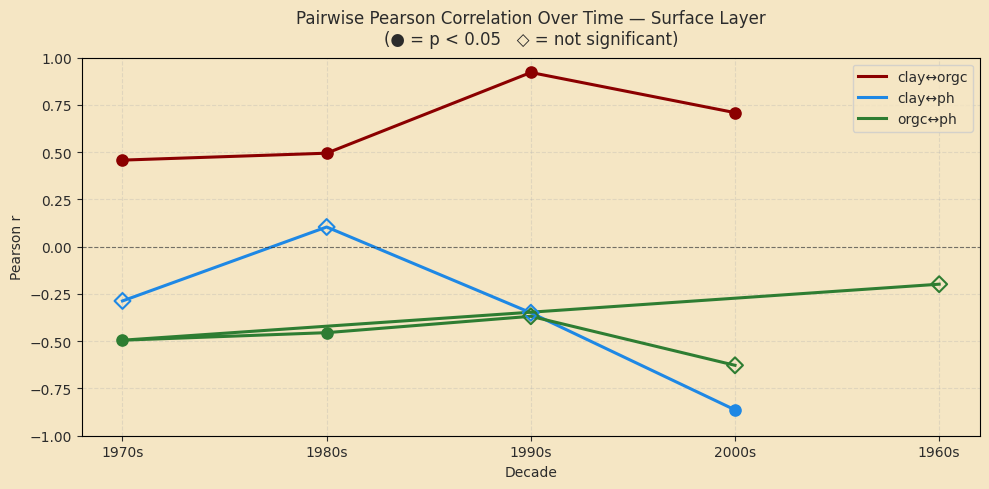

In [15]:
PAIR_COLORS = {
    "clay↔orgc": PALETTE["acid"],
    "orgc↔ph":   PALETTE["neutral"],
    "clay↔ph":   PALETTE["alkaline"]
}

fig, ax = plt.subplots(figsize=(10, 5))

for pair, grp in corr_df.groupby("pair"):
    grp_s = grp.sort_values("decade")
    sig   = grp_s[grp_s["p"] < 0.05]
    insig = grp_s[grp_s["p"] >= 0.05]

    ax.plot(grp_s["decade"], grp_s["r"],
            color=PAIR_COLORS[pair], linewidth=2.2, label=pair)
    ax.scatter(sig["decade"],   sig["r"],
               color=PAIR_COLORS[pair], s=65, zorder=5)
    ax.scatter(insig["decade"], insig["r"],
               color=PAIR_COLORS[pair], s=65, zorder=5,
               marker="D", facecolors="none", linewidths=1.5)

ax.axhline(0, color=PALETTE["charcoal"], linewidth=0.8,
           linestyle="--", alpha=0.6)
ax.set_ylim(-1, 1)
ax.set_title("Pairwise Pearson Correlation Over Time — Surface Layer\n"
             "(● = p < 0.05   ◇ = not significant)",
             color=PALETTE["charcoal"], fontsize=12, pad=10)
ax.set_xlabel("Decade",    color=PALETTE["charcoal"])
ax.set_ylabel("Pearson r", color=PALETTE["charcoal"])
ax.tick_params(colors=PALETTE["charcoal"])
ax.legend(facecolor=PALETTE["sand"], labelcolor=PALETTE["charcoal"])
clean_plot()
plt.show()

## 3.9 SSBI — Spatiotemporal Soil Behaviour Index

A composite score that collapses all three variables into a single normalised index per cell per decade. Each variable is min-max normalised within its decade, then averaged equally across variables.

The **delta map** shows composite change between the earliest and latest dateable decades: green = improvement across variables, red = degradation.

In [16]:
def min_max_norm(series):
    s_min, s_max = series.min(), series.max()
    if s_max == s_min:
        return pd.Series(0.0, index=series.index)
    return (series - s_min) / (s_max - s_min)


ssbi_parts = []
for decade in DECADE_ORDER:
    decade_data = surface[surface["decade"] == decade]
    wide = (
        decade_data
        .groupby(["cell_id", "lon_bin", "lat_bin", "variable"])["value_avg"]
        .mean()
        .unstack()
    )
    wide.columns.name = None
    for col in wide.columns:
        wide[col] = min_max_norm(wide[col])
    wide["ssbi"] = wide.mean(axis=1)
    wide = wide.reset_index()
    wide["decade"] = decade
    ssbi_parts.append(wide[["cell_id", "lon_bin", "lat_bin", "ssbi", "decade"]])

ssbi_df = pd.concat(ssbi_parts, ignore_index=True).dropna(subset=["ssbi"])
print(f"SSBI computed: {len(ssbi_df):,} cell–decade pairs")
print(f"Decade range : {ssbi_df['decade'].min()} – {ssbi_df['decade'].max()}")

SSBI computed: 94 cell–decade pairs
Decade range : 1940s – 2000s


In [17]:
earliest_decade = DECADE_ORDER[0]
latest_decade   = DECADE_ORDER[-1]

ssbi_early = (ssbi_df[ssbi_df["decade"] == earliest_decade]
              [["cell_id", "ssbi"]].rename(columns={"ssbi": "ssbi_early"}))
ssbi_late  = (ssbi_df[ssbi_df["decade"] == latest_decade]
              [["cell_id", "ssbi", "lon_bin", "lat_bin"]]
              .rename(columns={"ssbi": "ssbi_late"}))

ssbi_delta = ssbi_late.merge(ssbi_early, on="cell_id", how="inner").dropna()
ssbi_delta["delta"] = ssbi_delta["ssbi_late"] - ssbi_delta["ssbi_early"]

print(f"Cells with data in both {earliest_decade} and {latest_decade}: {len(ssbi_delta)}")
print(f"Delta range: {ssbi_delta['delta'].min():.3f} to {ssbi_delta['delta'].max():.3f}")

Cells with data in both 1940s and 2000s: 0
Delta range: nan to nan


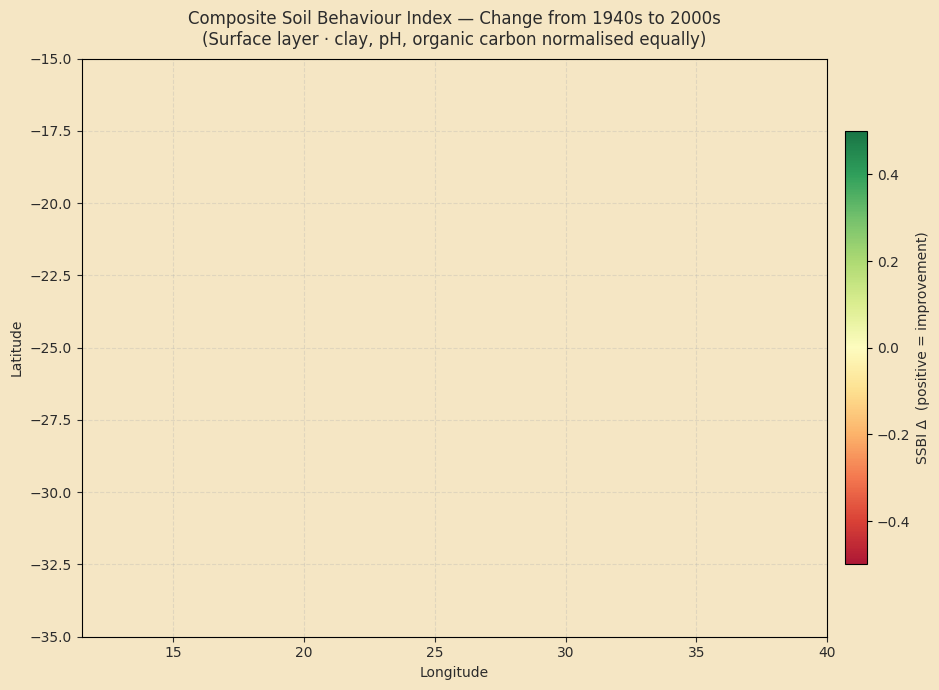

In [18]:
fig, ax = plt.subplots(figsize=(10, 7))
sc = ax.scatter(
    ssbi_delta["lon_bin"], ssbi_delta["lat_bin"],
    c=ssbi_delta["delta"],
    cmap="RdYlGn", vmin=-0.5, vmax=0.5,
    s=130, edgecolors=PALETTE["charcoal"], linewidths=0.3, alpha=0.9
)
cb = plt.colorbar(sc, ax=ax, shrink=0.75, pad=0.02)
cb.set_label("SSBI Δ  (positive = improvement)", color=PALETTE["charcoal"])
cb.ax.tick_params(labelcolor=PALETTE["charcoal"])
ax.set_xlim(BBOX["lon_min"], BBOX["lon_max"])
ax.set_ylim(BBOX["lat_min"], BBOX["lat_max"])
ax.set_facecolor(PALETTE["sand"])
ax.set_title(f"Composite Soil Behaviour Index — Change from {earliest_decade} to {latest_decade}\n"
             "(Surface layer · clay, pH, organic carbon normalised equally)",
             color=PALETTE["charcoal"], fontsize=12, pad=10)
ax.set_xlabel("Longitude", color=PALETTE["charcoal"])
ax.set_ylabel("Latitude",  color=PALETTE["charcoal"])
ax.tick_params(colors=PALETTE["charcoal"])
clean_plot()
plt.show()